In [1]:
#Intro
'This is Lorna Makena and this is WEEK 1!'

'This is Lorna Makena and this is WEEK 1!'

In [2]:
import pandas as pd

In [3]:
#Loading of the dataset
df = pd.read_csv(
    r"C:\Users\HP\AppData\Local\Temp\MicrosoftEdgeDownloads\dc3e84d3-442e-483d-8447-ac2061efbca7\OnlineRetail.csv\OnlineRetail.csv",
    encoding="latin1"
)

In [4]:
#Display of the first few rows
df.head(7)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom


In [5]:
#Here are the number of rows and columns in the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
#Here are the data types of each of the columns
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

In [7]:
#These are the numerical features of the set
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [8]:
#Categorical features
categorical_cols = df.select_dtypes(include='object').columns
print(categorical_cols)

Index(['InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'Country'], dtype='object')


In [9]:
#Check every column for uniqueness
for col in df.columns:
    print(col, df[col].is_unique)

InvoiceNo False
StockCode False
Description False
Quantity False
InvoiceDate False
UnitPrice False
CustomerID False
Country False


In [10]:
from itertools import combinations

In [11]:
#None of the individual columns in THE dataset are unique on their own, so there's no single-column primary key. 

#InvoiceNo repeats — one invoice can have many line items (one row per product purchased in that transaction)
#StockCode repeats — the same product appears across many different invoices
#CustomerID repeats — customers make multiple purchases
#Description, Quantity, UnitPrice, InvoiceDate, Country — none of these are unique identifiers by nature
#A composite key likely exists however:

cols = df.columns.tolist()

results = []
for pair in combinations(cols, 2):
    dup_count = df.duplicated(subset=list(pair)).sum()
    results.append((pair, dup_count))

results.sort(key=lambda x: x[1])
for pair, count in results:
    print(f"{pair}: {count} duplicates")

('InvoiceNo', 'StockCode'): 10684 duplicates
('InvoiceNo', 'Description'): 10869 duplicates
('StockCode', 'InvoiceDate'): 13028 duplicates
('Description', 'InvoiceDate'): 13574 duplicates
('Description', 'CustomerID'): 269197 duplicates
('StockCode', 'CustomerID'): 270484 duplicates
('InvoiceNo', 'UnitPrice'): 337180 duplicates
('InvoiceDate', 'UnitPrice'): 342767 duplicates
('InvoiceNo', 'Quantity'): 413291 duplicates
('Quantity', 'InvoiceDate'): 416931 duplicates
('UnitPrice', 'CustomerID'): 462842 duplicates
('Quantity', 'CustomerID'): 494274 duplicates
('StockCode', 'Quantity'): 496629 duplicates
('Description', 'Quantity'): 496971 duplicates
('InvoiceNo', 'InvoiceDate'): 515966 duplicates
('InvoiceNo', 'CustomerID'): 516009 duplicates
('InvoiceNo', 'Country'): 516009 duplicates
('InvoiceDate', 'CustomerID'): 516714 duplicates
('InvoiceDate', 'Country'): 518293 duplicates
('Description', 'Country'): 521732 duplicates
('StockCode', 'Country'): 522070 duplicates
('StockCode', 'UnitPr

In [12]:
#0 duplicates means that pair could serve as a composite key; anything higher tells you how far off it is

In [13]:
#Description of the dataset
df.describe

<bound method NDFrame.describe of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

            InvoiceDate  UnitPrice  Custo

In [14]:
#Columns with missing values
df.isnull()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
541904,False,False,False,False,False,False,False,False
541905,False,False,False,False,False,False,False,False
541906,False,False,False,False,False,False,False,False
541907,False,False,False,False,False,False,False,False


In [15]:
#Sum of missing values per column
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [16]:
#Does each InvoiceNo really map to only one CustomerID?
invoice_customer_counts = df.groupby('InvoiceNo')['CustomerID'].nunique()
print(invoice_customer_counts[invoice_customer_counts > 1])

Series([], Name: CustomerID, dtype: int64)


In [17]:
#Check for InvoiceNos that have a missing CustomerID
missing_customer_invoices = df[df['CustomerID'].isnull()]['InvoiceNo'].unique()
print(missing_customer_invoices)
print(len(missing_customer_invoices))

['536414' '536544' '536545' ... '581492' '581497' '581498']
3710


In [18]:
#This is the step that actually tells you whether the 1-to-1 relationship helps you recover anything.
# e.g imagine invoice 536414 has 5 product line items (5 rows). 
# What if 4 of those rows have CustomerID missing, but the 5th row — for some reason, maybe a data entry slip, actually has the CustomerID filled in?
recoverable = df[
    (df['InvoiceNo'].isin(missing_customer_invoices)) &
    (df['CustomerID'].notnull())
]
print(recoverable[['InvoiceNo', 'CustomerID']].drop_duplicates())
print("Number of recoverable rows:", recoverable.shape[0])


Empty DataFrame
Columns: [InvoiceNo, CustomerID]
Index: []
Number of recoverable rows: 0


In [19]:
#Fill in the missing values in the CustomerID column
df['CustomerID'] = df['CustomerID'].fillna(-1).astype('int64')

In [20]:
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID       int64
Country         object
dtype: object

In [21]:
#Check for a random handful of the imputed values just to make sure imputation went through well enough
df[df['CustomerID'] == -1].sample(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
481322,577358,22193,RED DINER WALL CLOCK,1,11/18/2011 15:59,16.63,-1,United Kingdom
173762,551719,47566,PARTY BUNTING,3,5/3/2011 16:09,10.79,-1,United Kingdom
352283,567671,23374,RED SPOT PAPER GIFT BAG,1,9/21/2011 15:34,1.63,-1,United Kingdom
67283,541830,47594A,CAROUSEL DESIGN WASHBAG,1,1/21/2011 17:09,1.63,-1,United Kingdom
455845,575649,21912,VINTAGE SNAKES & LADDERS,4,11/10/2011 14:23,3.75,-1,United Kingdom
208874,555150,21094,SET/6 RED SPOTTY PAPER PLATES,4,5/31/2011 15:53,0.83,-1,United Kingdom
509146,579297,21042,RED RETROSPOT APRON,1,11/29/2011 11:23,12.46,-1,United Kingdom
431268,573585,84992,72 SWEETHEART FAIRY CAKE CASES,6,10/31/2011 14:41,1.25,-1,United Kingdom
162083,550496,22913,RED COAT RACK PARIS FASHION,3,4/18/2011 15:05,4.95,-1,United Kingdom
330649,565919,20724,RED RETROSPOT CHARLOTTE BAG,3,9/7/2011 16:48,1.63,-1,United Kingdom


In [22]:
# Find StockCodes that have at least one missing Description
missing_desc_stockcodes = df[df['Description'].isnull()]['StockCode'].unique()
print(len(missing_desc_stockcodes))

# Check if any of those StockCodes have a valid Description elsewhere in the dataset
recoverable_desc = df[
    (df['StockCode'].isin(missing_desc_stockcodes)) &
    (df['Description'].notnull())
]
print(recoverable_desc[['StockCode', 'Description']].drop_duplicates())
print("Number of recoverable rows:", recoverable_desc.shape[0])

960
       StockCode                          Description
2         84406B       CREAM CUPID HEARTS COAT HANGER
3         84029G  KNITTED UNION FLAG HOT WATER BOTTLE
4         84029E       RED WOOLLY HOTTIE WHITE HEART.
7          22633               HAND WARMER UNION JACK
8          22632            HAND WARMER RED POLKA DOT
...          ...                                  ...
522163     16045                                check
522246     21868                               Amazon
524369     23406                                CHECK
524375    84876B                                found
524474     21804                               dotcom

[1104 rows x 2 columns]
Number of recoverable rows: 83298


In [23]:
#Check how many Descriptions exist per StockCode (distribution)
df_sales = df.copy()

desc_per_code = df_sales.groupby('StockCode')['Description'].nunique()
print(desc_per_code.value_counts())

Description
1    3308
2     517
0     112
3      98
4      26
5       5
6       2
8       1
7       1
Name: count, dtype: int64


In [24]:
#Check for which StockCodes have more than 1 description
inconsistent_codes = desc_per_code[desc_per_code > 1]
print(inconsistent_codes)
print(f"Number of inconsistent StockCodes: {len(inconsistent_codes)}")

StockCode
10080           2
10133           2
15058A          2
15058C          2
16008           2
               ..
90195A          2
90210D          2
DCGS0003        2
DCGS0069        2
gift_0001_20    2
Name: Description, Length: 650, dtype: int64
Number of inconsistent StockCodes: 650


In [25]:
#Check what those inconsistencies actually are
for code in inconsistent_codes.index:
    print(code, ":", df_sales[df_sales['StockCode'] == code]['Description'].unique())

10080 : ['GROOVY CACTUS INFLATABLE' nan 'check']
10133 : ['COLOURING PENCILS BROWN TUBE' 'damaged']
15058A : ['BLUE POLKADOT GARDEN PARASOL' nan 'wet/rusty']
15058C : ['ICE CREAM DESIGN GARDEN PARASOL' 'wet/rusty']
16008 : ['SMALL FOLDING SCISSOR(POINTED EDGE)' 'check']
16045 : ['POPART WOODEN PENCILS ASST' nan 'check']
16156L : ['WRAP, CAROUSEL' 'WRAP CAROUSEL']
16162M : [nan 'alan hodge cant mamage this section' 'THE KING GIFT BAG 25x24x12cm']
16168M : ['FUNKY MONKEY GIFT BAG MEDIUM' 'found']
16169E : ["WRAP 50'S  CHRISTMAS" 'check']
16207A : ['PINK STRAWBERRY HANDBAG ' 'check' nan]
17012B : ['ORIGAMI JASMINE INCENSE/CANDLE SET' 'check' nan]
17012C : ['ORIGAMI LAVENDER INCENSE/CANDL SET ' 'check']
17012F : ['ORIGAMI SANDLEWOOD INCENSE/CAND SET' 'check']
17091A : ['LAVENDER INCENSE IN TIN' nan 'found']
17107D : ["FLOWER FAIRY,5 SUMMER B'DRAW LINERS" 'FLOWER FAIRY 5 DRAWER LINERS'
 'FLOWER FAIRY 5 SUMMER DRAW LINERS']
17109D : ['FLOWER FAIRY INCENSE BOUQUET' 'Adjustment']
17136A : ['BL

In [26]:
#% of StockCodes that are clean (show that the StockCode is indeed a reliable predictor of Description)
clean_pct = (desc_per_code == 1).sum() / len(desc_per_code) * 100
print(f"{clean_pct:.2f}% of StockCodes have exactly one Description")

81.28% of StockCodes have exactly one Description


In [27]:
#Normalization before imputation of the Description column
df['Description_clean'] = (
    df['Description']
    .str.upper()                      # standardize case
    .str.replace(',', '', regex=False)  # remove commas
    .str.replace(r'\s+', ' ', regex=True)  # collapse multiple spaces into one
    .str.strip()                      # remove leading/trailing whitespace
)

In [28]:
#Check if it has reduced the number of inconsistent StockCode counts
desc_per_code_clean = df.groupby('StockCode')['Description_clean'].nunique()
print(desc_per_code_clean.value_counts())

Description_clean
1    3323
2     507
0     112
3      95
4      24
5       5
7       2
6       2
Name: count, dtype: int64


In [29]:
#Find all the junk values in the dataset
unique_descs = df['Description_clean'].dropna().unique()

# Flag anything that looks suspicious
suspicious = [d for d in unique_descs if len(d) < 12]
print(sorted(suspicious))
print(len(suspicious))

['20713', '?', '??', '?? MISSING', '???', '????MISSING', '???LOST', '???MISSING', '?DISPLAY?', '?LOST', '?MISSING', 'ADJUST', 'ADJUSTMENT', 'AMAZON', 'AMAZON FEE', 'BINGO SET', 'BREAKAGES', 'BROKEN', 'BUTTON BOX', "CAN'T FIND", 'CARRIAGE', 'CHECK', 'CHECK?', 'CORDIAL JUG', 'COUNTED', 'CRACKED', 'CRUSHED', 'CRUSHED CTN', 'DAGAMED', 'DAMAGED', 'DAMAGES', 'DAMAGES WAX', 'DAMAGES?', 'DISCOUNT', 'DISPLAY', 'DOTCOM', 'DOTCOM SET', 'DOTCOMSTOCK', 'EBAY', 'FAULTY', 'FBA', 'FOUND', 'FOUND BOX', 'FROG CANDLE', 'GIVEN AWAY', 'JOHN LEWIS', 'LOST', 'LOST??', 'MAILOUT', 'MANUAL', 'MIA', 'MICHEL OOPS', 'MISSING', 'MISSING?', 'MIXED UP', 'MOULDY', 'PHOTO CUBE', 'POSTAGE', 'RAIN PONCHO', 'RETURNED', 'SALE ERROR', 'SAMPLES', 'SHOWROOM', 'SKULLS TAPE', 'SMASHED', 'SOLD AS 1', 'SOMBRERO', 'SPACE FROG', 'SPACE OWL', 'STOCK CHECK', 'TAIG ADJUST', 'TEST', 'THROW AWAY', 'THROWN AWAY', 'TOYBOX WRAP', 'WET', 'WET BOXES', 'WET DAMAGED', 'WET PALLET', 'WET RUSTY', 'WET/MOULDY', 'WET/RUSTY', 'WET?', 'WICKER STAR',

In [30]:
#How many times do these values appear
for val in sorted(suspicious):
    count = (df['Description_clean'] == val).sum()
    print(f"{val}: {count}")

20713: 1
?: 47
??: 7
?? MISSING: 1
???: 1
????MISSING: 1
???LOST: 1
???MISSING: 2
?DISPLAY?: 1
?LOST: 1
?MISSING: 2
ADJUST: 1
ADJUSTMENT: 18
AMAZON: 18
AMAZON FEE: 34
BINGO SET: 387
BREAKAGES: 1
BROKEN: 1
BUTTON BOX: 256
CAN'T FIND: 1
CARRIAGE: 143
CHECK: 162
CHECK?: 1
CORDIAL JUG: 2
COUNTED: 2
CRACKED: 1
CRUSHED: 3
CRUSHED CTN: 1
DAGAMED: 1
DAMAGED: 58
DAMAGES: 46
DAMAGES WAX: 2
DAMAGES?: 5
DISCOUNT: 77
DISPLAY: 1
DOTCOM: 7
DOTCOM SET: 1
DOTCOMSTOCK: 1
EBAY: 5
FAULTY: 1
FBA: 1
FOUND: 34
FOUND BOX: 1
FROG CANDLE: 21
GIVEN AWAY: 1
JOHN LEWIS: 1
LOST: 1
LOST??: 1
MAILOUT: 4
MANUAL: 572
MIA: 1
MICHEL OOPS: 1
MISSING: 4
MISSING?: 1
MIXED UP: 2
MOULDY: 1
PHOTO CUBE: 331
POSTAGE: 1252
RAIN PONCHO: 6
RETURNED: 2
SALE ERROR: 1
SAMPLES: 64
SHOWROOM: 1
SKULLS TAPE: 73
SMASHED: 4
SOLD AS 1: 2
SOMBRERO: 61
SPACE FROG: 56
SPACE OWL: 71
STOCK CHECK: 2
TAIG ADJUST: 2
TEST: 3
THROW AWAY: 1
THROWN AWAY: 9
TOYBOX WRAP: 24
WET: 1
WET BOXES: 1
WET DAMAGED: 5
WET PALLET: 3
WET RUSTY: 2
WET/MOULDY: 1
WET/RU

In [31]:
junk_values = [
    '20713', '?', '??', '?? MISSING', '???', '????MISSING', '???LOST', '???MISSING',
    '?DISPLAY?', '?LOST', '?MISSING', 'ADJUST', 'ADJUSTMENT', 'AMAZON', 'AMAZON FEE',
    'BREAKAGES', 'BROKEN', "CAN'T FIND", 'CHECK', 'CHECK?', 'COUNTED', 'CRACKED',
    'CRUSHED', 'CRUSHED CTN', 'DAGAMED', 'DAMAGED', 'DAMAGES', 'DAMAGES WAX',
    'DAMAGES?', 'DISCOUNT', 'DISPLAY', 'DOTCOM', 'DOTCOM SET', 'DOTCOMSTOCK',
    'EBAY', 'FAULTY', 'FBA', 'FOUND', 'FOUND BOX', 'GIVEN AWAY', 'JOHN LEWIS',
    'LOST', 'LOST??', 'MAILOUT', 'MIA', 'MICHEL OOPS', 'MISSING', 'MISSING?',
    'MIXED UP', 'MOULDY', 'RETURNED', 'SALE ERROR', 'SAMPLES', 'SHOWROOM',
    'SMASHED', 'SOLD AS 1', 'STOCK CHECK', 'TAIG ADJUST', 'TEST', 'THROW AWAY',
    'THROWN AWAY', 'WET', 'WET BOXES', 'WET DAMAGED', 'WET PALLET', 'WET RUSTY',
    'WET/MOULDY', 'WET/RUSTY', 'WET?', 'WRONG CODE', 'WRONG CODE?'
]

#Match the StockCodes to the most legitimate Description (Mapping)
clean_df = df[~df['Description_clean'].isin(junk_values)]

stockcode_to_desc = (
    clean_df.dropna(subset=['Description_clean'])
    .groupby('StockCode')['Description_clean']
    .agg(lambda x: x.mode()[0])
)

#Imputation
df['Description_clean'] = df['Description_clean'].fillna(df['StockCode'].map(stockcode_to_desc))

#Check for what's still remaining unimputed
print(df['Description_clean'].isnull().sum())

113


In [32]:
#Fill in the unrecoverale remainders with a placeholder
df['Description_clean'] = df['Description_clean'].fillna('Unknown')

print(df['Description_clean'].isnull().sum())

0


In [33]:
# by checking rows where Description (original) is null but Description_clean is not
was_missing = df['Description'].isnull()
print(was_missing.sum())  # sanity check — should match your original 1,454

#Print a random sample of rows that have just been imputed
imputed_sample = df[was_missing].sample(25, random_state=42)
print(imputed_sample[['StockCode', 'Description', 'Description_clean']])

1454
       StockCode Description                    Description_clean
146597    84507B         NaN           STRIPES DESIGN MONKEY DOLL
373677    85086A         NaN          CANDY SPOT HEART DECORATION
136272     20713         NaN                       JUMBO BAG OWLS
332407     20686         NaN    DOLLY MIXTURE CHILDREN'S UMBRELLA
280661     77081         NaN                              Unknown
150620     85146         NaN   JARDIN ETCHED GLASS SMALL BELL JAR
75236      47579         NaN            TEA TIME BREAKFAST BASKET
332823     23306         NaN      SET OF 36 DOILIES PANTRY DESIGN
341596    84708B         NaN            PINK JEWELLED PHOTO FRAME
230350     21095         NaN            SET/6 POSIES PAPER PLATES
293905     21359         NaN             RELAX LARGE WOOD LETTERS
150601    84910A         NaN           PINK PAISLEY CUSHION COVER
281453     20666         NaN                ECONOMY HOLIDAY PURSE
148563     79331         NaN        PINK FLOCK GLASS CANDLEHOLDER
20232

In [34]:
#Cross-check each sampled row's StockCode against other rows in the dataset, to confirm the filled value 
#actually matches what that StockCode normally looks like elsewhere

for code in imputed_sample['StockCode'].unique()[:10]:
    other_rows = df[(df['StockCode'] == code) & (~was_missing)]['Description_clean'].unique()
    filled_value = imputed_sample[imputed_sample['StockCode'] == code]['Description_clean'].values[0]
    print(f"{code} -> filled with: '{filled_value}' | seen elsewhere as: {other_rows}")

84507B -> filled with: 'STRIPES DESIGN MONKEY DOLL' | seen elsewhere as: ['STRIPES DESIGN MONKEY DOLL']
85086A -> filled with: 'CANDY SPOT HEART DECORATION' | seen elsewhere as: ['CANDY SPOT HEART DECORATION']
20713 -> filled with: 'JUMBO BAG OWLS' | seen elsewhere as: ['JUMBO BAG OWLS' 'WRONGLY MARKED. 23343 IN BOX' 'WRONGLY CODED-23343'
 'FOUND' 'WRONGLY MARKED 23343' 'MARKED AS 23343' 'WRONGLY CODED 23343']
20686 -> filled with: 'DOLLY MIXTURE CHILDREN'S UMBRELLA' | seen elsewhere as: ["DOLLY MIXTURE CHILDREN'S UMBRELLA"]
77081 -> filled with: 'Unknown' | seen elsewhere as: []
85146 -> filled with: 'JARDIN ETCHED GLASS SMALL BELL JAR' | seen elsewhere as: ['JARDIN ETCHED GLASS SMALL BELL JAR']
47579 -> filled with: 'TEA TIME BREAKFAST BASKET' | seen elsewhere as: ['TEA TIME BREAKFAST BASKET']
23306 -> filled with: 'SET OF 36 DOILIES PANTRY DESIGN' | seen elsewhere as: ['SET OF 36 DOILIES PANTRY DESIGN' 'SET OF 36 PANTRY PAPER DOILIES']
84708B -> filled with: 'PINK JEWELLED PHOTO FRA

In [35]:
#Select non-product codes in the StockCode column
non_product_codes = [
    'AMAZONFEE', 'B', 'BANK CHARGES', 'C2', 'CRUK', 
    'D', 'DOT', 'M', 'POST', 'S'
]

#Create a flag colum so that no data is lost
df['is_product'] = ~df['StockCode'].isin(non_product_codes)

#Check for the impact
print(df['is_product'].value_counts())
print("Non-product rows:", (~df['is_product']).sum())

is_product
True     538998
False      2911
Name: count, dtype: int64
Non-product rows: 2911


In [36]:
#Random sapmle check  of the changes made so far
df.sample(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Description_clean,is_product
356369,568049,23158,SET OF 5 LUCKY CAT MAGNETS,1,9/23/2011 12:38,2.08,17841,United Kingdom,SET OF 5 LUCKY CAT MAGNETS,True
118585,546440,82482,WOODEN PICTURE FRAME WHITE FINISH,6,3/14/2011 10:31,2.55,16871,United Kingdom,WOODEN PICTURE FRAME WHITE FINISH,True
168652,551125,90164A,PINK ROSEBUD PEARL BRACELET,2,4/26/2011 12:47,7.50,17277,United Kingdom,PINK ROSEBUD PEARL BRACELET,True
133889,547803,22986,GINGHAM ROSE WRAP,25,3/25/2011 13:23,0.42,13662,United Kingdom,GINGHAM ROSE WRAP,True
519669,580160,23508,MINI PLAYING CARDS DOLLY GIRL,20,12/2/2011 10:47,0.42,12700,France,MINI PLAYING CARDS DOLLY GIRL,True
274347,560901,22971,QUEENS GUARD COFFEE MUG,6,7/21/2011 17:39,2.55,12476,Germany,QUEENS GUARD COFFEE MUG,True
131349,547554,21340,CLASSIC METAL BIRDCAGE PLANT HOLDER,8,3/23/2011 16:22,9.95,17858,United Kingdom,CLASSIC METAL BIRDCAGE PLANT HOLDER,True
133682,547790,85049C,ROMANTIC PINKS RIBBONS,12,3/25/2011 12:04,1.25,12545,Spain,ROMANTIC PINKS RIBBONS,True
381636,569870,23388,WOODLAND MINI BACKPACK,2,10/6/2011 14:59,4.15,12757,Portugal,WOODLAND MINI BACKPACK,True
484776,577541,22382,LUNCH BAG SPACEBOY DESIGN,10,11/20/2011 14:31,1.65,16899,United Kingdom,LUNCH BAG SPACEBOY DESIGN,True


In [37]:
#Check for the number of rows with negative values in the Quantity column
print((df['Quantity'] < 0).sum())

10624


In [38]:
# Confirm that every invoice starting with "C" (cancellations) has a negative quantity, with no exceptions
cancelled = df[df['InvoiceNo'].astype(str).str.startswith('C')]
print("Total C-invoices rows:", cancelled.shape[0])
print("Min quantity:", cancelled['Quantity'].min())
print("Max quantity:", cancelled['Quantity'].max())
print("Any positive quantities?:", (cancelled['Quantity'] > 0).any())

Total C-invoices rows: 9288
Min quantity: -80995
Max quantity: -1
Any positive quantities?: False


In [39]:
check = df[df['InvoiceNo'].isin(['C536548', 'C536543', 'C536506', 'C536391', 'C536383', 'C536379'])]
print(check[['InvoiceNo', 'StockCode', 'Description', 'Quantity']])

     InvoiceNo StockCode                          Description  Quantity
141    C536379         D                             Discount        -1
154    C536383    35004C      SET OF 3 COLOURED  FLYING DUCKS        -1
235    C536391     22556       PLASTERS IN TIN CIRCUS PARADE        -12
236    C536391     21984     PACK OF 12 PINK PAISLEY TISSUES        -24
237    C536391     21983     PACK OF 12 BLUE PAISLEY TISSUES        -24
238    C536391     21980    PACK OF 12 RED RETROSPOT TISSUES        -24
239    C536391     21484          CHICK GREY HOT WATER BOTTLE       -12
240    C536391     22557     PLASTERS IN TIN VINTAGE PAISLEY        -12
241    C536391     22553               PLASTERS IN TIN SKULLS       -24
939    C536506     22960             JAM MAKING SET WITH JARS        -6
1441   C536543     22632            HAND WARMER RED RETROSPOT        -1
1442   C536543     22355            CHARLOTTE BAG SUKI DESIGN        -2
1973   C536548     22244           3 HOOK HANGER MAGIC GARDEN   

In [40]:
#Check for negative prices in the UnitPrice column
neg_price = df[df['UnitPrice'] < 0]
print(neg_price.shape[0])
print(neg_price[['InvoiceNo', 'StockCode', 'Description', 'Description_clean', 'Quantity', 'UnitPrice', 'CustomerID']])

2
       InvoiceNo StockCode      Description Description_clean  Quantity  \
299983   A563186         B  Adjust bad debt   ADJUST BAD DEBT         1   
299984   A563187         B  Adjust bad debt   ADJUST BAD DEBT         1   

        UnitPrice  CustomerID  
299983  -11062.06          -1  
299984  -11062.06          -1  


In [41]:
#Full distribution of first-characters across InvoiceNo
print(df['InvoiceNo'].astype(str).str[0].value_counts())

InvoiceNo
5    532618
C      9288
A         3
Name: count, dtype: int64


In [42]:
#This shows you all 3 "A" rows together
print(df[df['InvoiceNo'].astype(str).str.startswith('A')])

       InvoiceNo StockCode      Description  Quantity      InvoiceDate  \
299982   A563185         B  Adjust bad debt         1  8/12/2011 14:50   
299983   A563186         B  Adjust bad debt         1  8/12/2011 14:51   
299984   A563187         B  Adjust bad debt         1  8/12/2011 14:52   

        UnitPrice  CustomerID         Country Description_clean  is_product  
299982   11062.06          -1  United Kingdom   ADJUST BAD DEBT       False  
299983  -11062.06          -1  United Kingdom   ADJUST BAD DEBT       False  
299984  -11062.06          -1  United Kingdom   ADJUST BAD DEBT       False  


In [43]:
#Delete these rows (don't really carry weight/ impact the dataset)
bad_debt_invoices = ['A563185', 'A563186', 'A563187']
df = df[~df['InvoiceNo'].isin(bad_debt_invoices)]

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 541906 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   InvoiceNo          541906 non-null  object 
 1   StockCode          541906 non-null  object 
 2   Description        540452 non-null  object 
 3   Quantity           541906 non-null  int64  
 4   InvoiceDate        541906 non-null  object 
 5   UnitPrice          541906 non-null  float64
 6   CustomerID         541906 non-null  int64  
 7   Country            541906 non-null  object 
 8   Description_clean  541906 non-null  object 
 9   is_product         541906 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(6)
memory usage: 41.9+ MB


In [45]:
#Drop the 'dirty' column: Description for Description_clean and rename it 'Description'
df_final = df.drop(columns=['Description']).rename(columns={'Description_clean': 'Description'})

In [46]:
#Get the datatype for the column InvoiceDate
print(df_final['InvoiceDate'].dtype)

object


In [47]:
#Convert into a proper datetime datatype
df_final['InvoiceDate'] = pd.to_datetime(df_final['InvoiceDate'])
print(df_final['InvoiceDate'].dtype)  

datetime64[ns]


In [48]:
#Final snapshot of the changes made in the dataset
for col in df_final.columns:
    print(f"\n--- {col} ---")
    print("Dtype:", df_final[col].dtype)
    print("Nulls:", df_final[col].isnull().sum())
    print("Unique values:", df_final[col].nunique())
    print(df_final[col].sample(20))


--- InvoiceNo ---
Dtype: object
Nulls: 0
Unique values: 25897
202401    554382
404940    571701
77232     542716
484214    577524
356388    568050
523752    580520
171694    551440
203594    554526
534065    581131
17582     537769
86842     543604
450754    575177
123381    546896
179882    552290
254330    559307
342901    566915
508985    579286
299316    563094
119397    546542
223814    556491
Name: InvoiceNo, dtype: object

--- StockCode ---
Dtype: object
Nulls: 0
Unique values: 4069
321404     23328
299513     22084
316113     23026
277014     84978
246589     22705
289000     20674
531723     22423
136824     22892
127766     21980
373204     21829
382456     22211
146091     21165
351737     23118
76453      48116
179087    90177D
200372     22335
266040     22747
240862    85099B
535337     23494
307454     22659
Name: StockCode, dtype: object

--- Quantity ---
Dtype: int64
Nulls: 0
Unique values: 722
463363     6
246897     2
67373      1
362569     6
396251     1
98337    

In [49]:
#Re-organize the new dataset
df_final = df_final[['CustomerID', 'InvoiceNo', 'StockCode', 'Description', 'Country', 
                        'is_product', 'InvoiceDate', 'Quantity', 'UnitPrice']]
                      

In [50]:
#New and clean datset
df_final.to_csv('Cleaned_Online_Retail.csv', index=False)

In [51]:
#Check back if everything's read correctly
df_final.to_csv('Cleaned_Online_Retail.csv', index=False)

df_final.sample(10)

,CustomerID,InvoiceNo,StockCode,Description,Country,is_product,InvoiceDate,Quantity,UnitPrice
241466,17841,558232,22755,SMALL PURPLE BABUSHKA NOTEBOOK,United Kingdom,True,2011-06-27 14:30:00,5,0.85
505591,14893,579091,23110,PARISIENNE KEY CABINET,United Kingdom,True,2011-11-28 10:49:00,2,5.75
367719,13503,568902,22623,BOX OF VINTAGE JIGSAW BLOCKS,United Kingdom,True,2011-09-29 13:23:00,3,5.95
114021,17639,546006,21671,RED SPOT CERAMIC DRAWER KNOB,United Kingdom,True,2011-03-08 15:22:00,18,1.25
238564,12697,557939,22937,BAKING MOULD CHOCOLATE CUPCAKES,Sweden,True,2011-06-23 15:44:00,6,2.55
490347,13488,578044,22909,SET OF 20 VINTAGE CHRISTMAS NAPKINS,United Kingdom,True,2011-11-22 14:41:00,24,0.85
353273,14646,567795,21481,FAWN BLUE HOT WATER BOTTLE,Netherlands,True,2011-09-22 11:44:00,8,3.75
390455,12371,570521,23355,HOT WATER BOTTLE KEEP CALM,Switzerland,True,2011-10-11 10:43:00,4,4.95
528571,-1,580729,23335,EGG FRYING PAN IVORY,United Kingdom,True,2011-12-05 17:24:00,1,4.13
26052,16779,538453,72807B,SET/3 OCEAN SCENT CANDLE JEWEL BOX,United Kingdom,True,2010-12-12 12:26:00,1,4.25


In [52]:
df_final.dtypes

CustomerID              int64
InvoiceNo              object
StockCode              object
Description            object
Country                object
is_product               bool
InvoiceDate    datetime64[ns]
Quantity                int64
UnitPrice             float64
dtype: object

In [53]:
#Check for duplicates
print(df_final.duplicated().sum())

5268


In [54]:
# See the actual duplicate rows, including both the original and its repeat(s)
df_final[df_final.duplicated(keep=False)].sort_values(by=list(df_final.columns))

,CustomerID,InvoiceNo,StockCode,Description,Country,is_product,InvoiceDate,Quantity,UnitPrice
14351,-1,537534,22520,CHILDS GARDEN TROWEL BLUE,United Kingdom,True,2010-12-07 11:48:00,1,0.00
14359,-1,537534,22520,CHILDS GARDEN TROWEL BLUE,United Kingdom,True,2010-12-07 11:48:00,1,0.00
33259,-1,539245,22951,60 CAKE CASES DOLLY GIRL DESIGN,United Kingdom,True,2010-12-16 13:25:00,1,0.55
33279,-1,539245,22951,60 CAKE CASES DOLLY GIRL DESIGN,United Kingdom,True,2010-12-16 13:25:00,1,0.55
40249,-1,539733,22962,JAM JAR WITH PINK LID,United Kingdom,True,2010-12-21 15:13:00,2,0.85
...,...,...,...,...,...,...,...,...,...
494134,18283,578262,84992,72 SWEETHEART FAIRY CAKE CASES,United Kingdom,True,2011-11-23 13:27:00,1,0.55
494151,18283,578262,84992,72 SWEETHEART FAIRY CAKE CASES,United Kingdom,True,2011-11-23 13:27:00,1,0.55
514085,18283,579673,23208,LUNCH BAG VINTAGE LEAF DESIGN,United Kingdom,True,2011-11-30 12:59:00,1,1.65
514093,18283,579673,23208,LUNCH BAG VINTAGE LEAF DESIGN,United Kingdom,True,2011-11-30 12:59:00,1,1.65


In [55]:
#Drop all those duplicates (5268)
df_final = df_final.drop_duplicates()

In [56]:
#Verify it worked
print(df_final.duplicated().sum()) 
print(df_final.shape) 

0
(536638, 9)


In [57]:
#Re-export the file so that the saved CSV reflects the latest clean-up
df_final.to_csv('Cleaned_Online_Retail.csv', index=False)

In [58]:
df_final.shape

(536638, 9)

In [59]:
#Check for current column names (standardization purposes)
print(df_final.columns.tolist())

['CustomerID', 'InvoiceNo', 'StockCode', 'Description', 'Country', 'is_product', 'InvoiceDate', 'Quantity', 'UnitPrice']


In [60]:
#Rename them all to PascalCase for consistency
df_final = df_final.rename(columns={
    'InvoiceNo': 'InvoiceNo',
    'CustomerID': 'CustomerID',
    'Country': 'Country',
    'InvoiceDate': 'InvoiceDate',
    'StockCode': 'StockCode',
    'Description': 'Description',
    'is_product': 'IsProduct',
    'Quantity': 'Quantity',
    'UnitPrice': 'UnitPrice'
})
print(df_final.columns.tolist())

['CustomerID', 'InvoiceNo', 'StockCode', 'Description', 'Country', 'IsProduct', 'InvoiceDate', 'Quantity', 'UnitPrice']


In [61]:
#For the sake of uniformity, let's apply UPPERCASE to all text columns
df_final['InvoiceNo'] = df_final['InvoiceNo'].str.upper()
df_final['StockCode'] = df_final['StockCode'].str.upper()
df_final['Description'] = df_final['Description'].str.upper()
df_final['Country'] = df_final['Country'].str.upper()

In [62]:
#Verift that it worked
df_final.sample(8)

,CustomerID,InvoiceNo,StockCode,Description,Country,IsProduct,InvoiceDate,Quantity,UnitPrice
104769,-1,545215,21454,PAINTED PINK RABBIT,UNITED KINGDOM,True,2011-02-28 16:47:00,4,0.83
507108,16800,579167,23074,EMBOSSED HEART TRINKET BOX,UNITED KINGDOM,True,2011-11-28 14:06:00,4,2.08
466847,-1,576329,23012,GLASS APOTHECARY BOTTLE PERFUME,UNITED KINGDOM,True,2011-11-14 15:22:00,1,8.29
439903,14388,574484,85099B,JUMBO BAG RED RETROSPOT,UNITED KINGDOM,True,2011-11-04 12:50:00,10,2.08
65647,-1,541696,22470,HEART OF WICKER LARGE,UNITED KINGDOM,True,2011-01-20 18:08:00,1,5.79
272962,-1,560773,21982,PACK OF 12 SUKI TISSUES,UNITED KINGDOM,True,2011-07-20 16:17:00,1,0.83
138787,12456,548212,22492,MINI PAINT SET VINTAGE,SWITZERLAND,True,2011-03-30 09:12:00,36,0.65
335511,14456,566290,22386,JUMBO BAG PINK POLKADOT,UNITED KINGDOM,True,2011-09-11 15:24:00,1,2.08


In [63]:
#Check for anomalies/outliers
df_final['Quantity'].describe()

count    536638.000000
mean          9.620077
std         219.130768
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64

In [64]:
df_final['UnitPrice'].describe()

count    536638.000000
mean          4.653295
std          93.648553
min           0.000000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64

In [65]:
#Check for the highest and lowest values directly
print(df_final['Quantity'].sort_values(ascending=False).head(10))
print(df_final['Quantity'].sort_values(ascending=True).head(10))

print(df_final['UnitPrice'].sort_values(ascending=False).head(10))
print(df_final['UnitPrice'].sort_values(ascending=True).head(10))

540421    80995
61619     74215
502122    12540
74614      5568
421632     4800
206121     4300
220843     4000
97432      3906
270885     3186
160546     3114
Name: Quantity, dtype: int64
540422   -80995
61624    -74215
225530    -9600
225529    -9600
4287      -9360
225528    -9058
115818    -5368
431381    -4830
341601    -3667
323458    -3167
Name: Quantity, dtype: int64
222681    38970.00
524602    17836.46
43702     16888.02
43703     16453.71
16356     13541.33
15017     13541.33
15016     13541.33
16232     13474.79
524601    11586.50
446533     8286.22
Name: UnitPrice, dtype: float64
265294    0.0
415319    0.0
331018    0.0
229728    0.0
80302     0.0
415318    0.0
80303     0.0
173241    0.0
137905    0.0
173242    0.0
Name: UnitPrice, dtype: float64


In [66]:
#Let's go the IQR method
def find_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f"{column}: {outliers.shape[0]} outliers (bounds: {lower_bound:.2f} to {upper_bound:.2f})")
    return outliers

qty_outliers = find_outliers_iqr(df_final, 'Quantity')
price_outliers = find_outliers_iqr(df_final, 'UnitPrice')

Quantity: 58501 outliers (bounds: -12.50 to 23.50)
UnitPrice: 39447 outliers (bounds: -3.07 to 8.45)


In [67]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [68]:
#Common sense extreme check
print(df_final[df_final['Quantity'] > 5000][['InvoiceNo', 'StockCode', 'Description', 'Quantity']].sort_values('Quantity', ascending=False))
print(df_final[df_final['UnitPrice'] > 500][['InvoiceNo', 'StockCode', 'Description', 'UnitPrice']].sort_values('UnitPrice', ascending=False))

       InvoiceNo StockCode                     Description  Quantity
540421    581483     23843       PAPER CRAFT LITTLE BIRDIE     80995
61619     541431     23166  MEDIUM CERAMIC TOP STORAGE JAR     74215
502122    578841     84826  ASSTD DESIGN 3D PAPER STICKERS     12540
74614     542504     37413          ICON MUG REVOLUTIONARY      5568
       InvoiceNo  StockCode      Description  UnitPrice
222681   C556445          M           MANUAL   38970.00
524602   C580605  AMAZONFEE       AMAZON FEE   17836.46
43702    C540117  AMAZONFEE       AMAZON FEE   16888.02
43703    C540118  AMAZONFEE       AMAZON FEE   16453.71
15017     537632  AMAZONFEE       AMAZON FEE   13541.33
...          ...        ...              ...        ...
466525    576329        DOT   DOTCOM POSTAGE     518.98
455284   C575606       CRUK  CRUK COMMISSION     517.51
40494     539737        DOT   DOTCOM POSTAGE     514.00
431508    573601        DOT   DOTCOM POSTAGE     511.25
34799     539434        DOT   DOTCOM PO

In [69]:
#Check whether it's the same customer placing these bulk orders
#Is this a one-off transaction with no other purchase history for the given products?
#Does the CustomerID show up as -1?

extreme_qty_codes = ['23843', '23166', '84826', '37413']

for code in extreme_qty_codes:
    print(f"\n--- StockCode: {code} ---")
    print(df_final[df_final['StockCode'] == code][['InvoiceNo', 'CustomerID', 'Quantity']])


--- StockCode: 23843 ---
       InvoiceNo  CustomerID  Quantity
540421    581483       16446     80995
540422   C581484       16446    -80995

--- StockCode: 23166 ---
       InvoiceNo  CustomerID  Quantity
61619     541431       12346     74215
61624    C541433       12346    -74215
186770    552882       14646        96
187196    552953       16745         4
187718    553005       14651         5
...          ...         ...       ...
533742    581108       15984         2
536248    581219          -1         1
539776    581439          -1         2
540301    581476       12433        48
541101    581492          -1         2

[260 rows x 3 columns]

--- StockCode: 84826 ---
       InvoiceNo  CustomerID  Quantity
3323      536620       14135        60
29066    C538702       13008       -60
29521     538801       16083        60
30536     538870       12829        60
31105     538895       14401        60
31991     539038       15641        60
32254     539050       12577         2
3

In [70]:
#Summary table
cleaning_summary = pd.DataFrame({
    'Issue Found': [
        'Missing Values — CustomerID (135,080 rows)',
        'Missing Values — Description (1,454 rows)',
        'Duplicates (5,268 rows)',
        'Invalid Entries — Non-product StockCodes',
        'Invalid Entries — Junk Description values',
        'Standardization — Text formatting (Description)',
        'Standardization — Column names',
        'Standardization — Data types',
        'Standardization — Text casing (all columns)',
        'Anomalies — "EIRE" in Country',
        'Anomalies — Bad debt entries (3 rows)',
        'Outliers — Quantity & UnitPrice (IQR-flagged)'
    ],
    'Action Taken': [
        'Filled with -1 as explicit placeholder for unattributed/guest transactions',
        'Recovered via StockCode-to-Description mapping; 113 unrecoverable rows filled with "Unknown"',
        'Removed via drop_duplicates() — kept first occurrence',
        'Flagged via new IsProduct column rather than deleted',
        'Identified via frequency/pattern analysis; excluded from mapping logic',
        'Normalized to uppercase, removed commas, collapsed whitespace',
        'Renamed to consistent PascalCase (e.g., IsProduct)',
        'InvoiceDate -> datetime64[ns], CustomerID -> int64',
        'Converted to uppercase across InvoiceNo, StockCode, Description, Country',
        'Investigated, confirmed legitimate (Ireland), no action taken',
        'Removed — non-product accounting entries unrelated to sales',
        'Investigated, retained — reflects natural skew of retail data, not errors'
    ]
})

cleaning_summary

,Issue Found,Action Taken
0,"Missing Values — CustomerID (135,080 rows)",Filled with -1 as explicit placeholder for una...
1,"Missing Values — Description (1,454 rows)",Recovered via StockCode-to-Description mapping...
2,"Duplicates (5,268 rows)",Removed via drop_duplicates() — kept first occ...
3,Invalid Entries — Non-product StockCodes,Flagged via new IsProduct column rather than d...
4,Invalid Entries — Junk Description values,Identified via frequency/pattern analysis; exc...
5,Standardization — Text formatting (Description),"Normalized to uppercase, removed commas, colla..."
6,Standardization — Column names,"Renamed to consistent PascalCase (e.g., IsProd..."
7,Standardization — Data types,"InvoiceDate -> datetime64[ns], CustomerID -> i..."
8,Standardization — Text casing (all columns),"Converted to uppercase across InvoiceNo, Stock..."
9,"Anomalies — ""EIRE"" in Country","Investigated, confirmed legitimate (Ireland), ..."


In [71]:
#Identify the numerical columns i the dataset
numerical_cols = df_final.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(numerical_cols)

['CustomerID', 'Quantity', 'UnitPrice']


In [72]:
#But it doesn't make sense to compute the CustomerID column so we proceed with the Quantity and UnitPrice columns
summary_stats = pd.DataFrame({
    'Mean': df_final[['Quantity', 'UnitPrice']].mean(),
    'Median': df_final[['Quantity', 'UnitPrice']].median(),
    'Minimum': df_final[['Quantity', 'UnitPrice']].min(),
    'Maximum': df_final[['Quantity', 'UnitPrice']].max(),
    'Standard Deviation': df_final[['Quantity', 'UnitPrice']].std()
})

summary_stats

,Mean,Median,Minimum,Maximum,Standard Deviation
Quantity,9.620077,3.00,-80995.0,80995.0,219.130768
UnitPrice,4.653295,2.08,0.0,38970.0,93.648553


In [73]:
#Add a Revenue column for Revenue and Sales Analysis
df_final['Revenue'] = df_final['Quantity'] * df_final['UnitPrice']

In [74]:
df_final.sample(15)

,CustomerID,InvoiceNo,StockCode,Description,Country,IsProduct,InvoiceDate,Quantity,UnitPrice,Revenue
182761,14680,552572,22355,CHARLOTTE BAG SUKI DESIGN,UNITED KINGDOM,True,2011-05-10 12:11:00,100,0.72,72.00
473632,-1,576837,22064,PINK DOUGHNUT TRINKET POT,UNITED KINGDOM,True,2011-11-16 15:16:00,1,3.29,3.29
97169,-1,544599,22615,PACK OF 12 CIRCUS PARADE TISSUES,UNITED KINGDOM,True,2011-02-21 18:15:00,1,0.83,0.83
391390,12536,570672,21245,GREEN POLKADOT PLATE,FRANCE,True,2011-10-11 14:52:00,8,1.69,13.52
128099,-1,547249,85194S,HANGING SPRING FLOWER EGG SMALL,UNITED KINGDOM,True,2011-03-22 09:27:00,1,1.63,1.63
86916,16842,543619,22635,CHILDS BREAKFAST SET DOLLY GIRL,UNITED KINGDOM,True,2011-02-10 14:51:00,2,9.95,19.90
48394,-1,540468,22027,TEA PARTY BIRTHDAY CARD,UNITED KINGDOM,True,2011-01-07 13:55:00,4,0.85,3.40
96169,14646,544479,22188,BLACK HEART CARD HOLDER,NETHERLANDS,True,2011-02-21 10:28:00,108,3.39,366.12
47441,16889,540415,85025C,PINK HEART SHAPE PHOTO FRAME,UNITED KINGDOM,True,2011-01-07 10:47:00,3,1.65,4.95
283197,15974,561698,22699,ROSES REGENCY TEACUP AND SAUCER,UNITED KINGDOM,True,2011-07-29 10:21:00,24,2.55,61.20


In [75]:
#Compute the gross revenue vs the net revenue

total_revenue_all = df_final['Revenue'].sum()
total_revenue_products_only = df_final[df_final['IsProduct']]['Revenue'].sum()

print(f"Net Revenue: £{total_revenue_all:,.2f}")
print(f"Gross Revenue: £{total_revenue_products_only:,.2f}")

Net Revenue: £9,737,069.01
Gross Revenue: £9,772,006.52


In [76]:
pip install itables

Note: you may need to restart the kernel to use updated packages.


In [77]:
df_final.columns

Index(['CustomerID', 'InvoiceNo', 'StockCode', 'Description', 'Country',
       'IsProduct', 'InvoiceDate', 'Quantity', 'UnitPrice', 'Revenue'],
      dtype='object')

In [78]:
#Summary by country and product
country_revenue = (
    df_final.groupby(['Country', 'Description'])['Revenue']
            .sum()
            .reset_index()
            .sort_values(['Country', 'Revenue'], ascending=[True, False])
)

In [79]:
#What are the top/worst products by revenue or quantity, in a specific country?
import ipywidgets as widgets
from IPython.display import display

country_product_data = (
    df_final
    .groupby(['Country', 'IsProduct', 'Description'])
    .agg(Revenue=('Revenue', 'sum'), Quantity=('Quantity', 'sum'))
    .reset_index()
)

country_dd = widgets.Dropdown(options=['All Countries'] + sorted(country_product_data['Country'].unique()),
                                value='All Countries', description='Country:')
type_dd = widgets.Dropdown(options=[('Products', True), ('Non-Products', False)],
                             value=True, description='Type:')
metric_dd = widgets.Dropdown(options=['Revenue', 'Quantity'], value='Revenue', description='Metric:')
sort_dd = widgets.Dropdown(options=[('Best First', False), ('Worst First', True)], 
                             value=False, description='Sort:')
output_a = widgets.Output()

def update_country_product_table(change=None):
    output_a.clear_output()
    with output_a:
        filtered = country_product_data[country_product_data['IsProduct'] == type_dd.value]
        
        if country_dd.value != 'All Countries':
            filtered = filtered[filtered['Country'] == country_dd.value]
        else:
            filtered = filtered.groupby('Description', as_index=False)[['Revenue', 'Quantity']].sum()
        
        filtered = filtered.sort_values(metric_dd.value, ascending=sort_dd.value).reset_index(drop=True)
        display(filtered)

country_dd.observe(update_country_product_table, names='value')
type_dd.observe(update_country_product_table, names='value')
metric_dd.observe(update_country_product_table, names='value')
sort_dd.observe(update_country_product_table, names='value')
display(country_dd, type_dd, metric_dd, sort_dd, output_a)
update_country_product_table()

Dropdown(description='Country:', options=('All Countries', 'AUSTRALIA', 'AUSTRIA', 'BAHRAIN', 'BELGIUM', 'BRAZ…

Dropdown(description='Type:', options=(('Products', True), ('Non-Products', False)), value=True)

Dropdown(description='Metric:', options=('Revenue', 'Quantity'), value='Revenue')

Dropdown(description='Sort:', options=(('Best First', False), ('Worst First', True)), value=False)

Output()

In [82]:
import pandas as pd
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display

In [83]:
#Visualization of the table above

country_revenue = (
    df_final.groupby(['Country', 'IsProduct', 'Description'])
            .agg(Revenue=('Revenue', 'sum'), Quantity=('Quantity', 'sum'))
            .reset_index()
)

country_dropdown = widgets.Dropdown(
    options=['All Countries'] + sorted(country_revenue['Country'].unique().tolist()),
    value='All Countries',
    description='Country:'
)
type_dropdown = widgets.Dropdown(
    options=[('Products', True), ('Non-Products', False)],
    value=True,
    description='Type:'
)
metric_dropdown = widgets.Dropdown(
    options=['Revenue', 'Quantity'],
    value='Revenue',
    description='Metric:'
)
sort_dropdown = widgets.Dropdown(
    options=[('Best First', False), ('Worst First', True)],
    value=False,
    description='Sort:'
)
top_n_slider = widgets.IntSlider(
    value=10,
    min=1,
    max=40,
    step=1,
    description='Top N:'
)
output = widgets.Output()

def update_chart(change=None):
    output.clear_output()
    metric = metric_dropdown.value
    ascending = sort_dropdown.value

    filtered = country_revenue[
        country_revenue['IsProduct'] == type_dropdown.value
    ]
    if country_dropdown.value != 'All Countries':
        filtered = filtered[filtered['Country'] == country_dropdown.value]
    else:
        filtered = filtered.groupby('Description', as_index=False)[['Revenue', 'Quantity']].sum()

    filtered = (
        filtered.groupby('Description')[metric]
                .sum()
                .reset_index()
                .sort_values(metric, ascending=ascending)
                .head(top_n_slider.value)
    )

    title_country = "All Countries" if country_dropdown.value == "All Countries" else country_dropdown.value
    title_type = "Products" if type_dropdown.value else "Non-Products"
    title_rank = "Worst" if ascending else "Top"

    fig = px.bar(
        filtered,
        x=metric,
        y="Description",
        orientation="h",
        text=metric,
        title=f"{title_rank} {top_n_slider.value} {title_type} by {metric} ({title_country})"
    )
    if metric == 'Revenue':
        fig.update_traces(texttemplate='£%{text:,.0f}', textposition='outside')
    else:
        fig.update_traces(texttemplate='%{text:,.0f}', textposition='outside')

    fig.update_layout(
        yaxis=dict(categoryorder='total ascending' if not ascending else 'total descending'),
        xaxis_title=metric,
        yaxis_title="Description",
        height=650,
        showlegend=False
    )
    with output:
        fig.show()

country_dropdown.observe(update_chart, names='value')
type_dropdown.observe(update_chart, names='value')
metric_dropdown.observe(update_chart, names='value')
sort_dropdown.observe(update_chart, names='value')
top_n_slider.observe(update_chart, names='value')

display(
    widgets.VBox([country_dropdown, type_dropdown, metric_dropdown, sort_dropdown, top_n_slider]),
    output
)
update_chart()

Output()

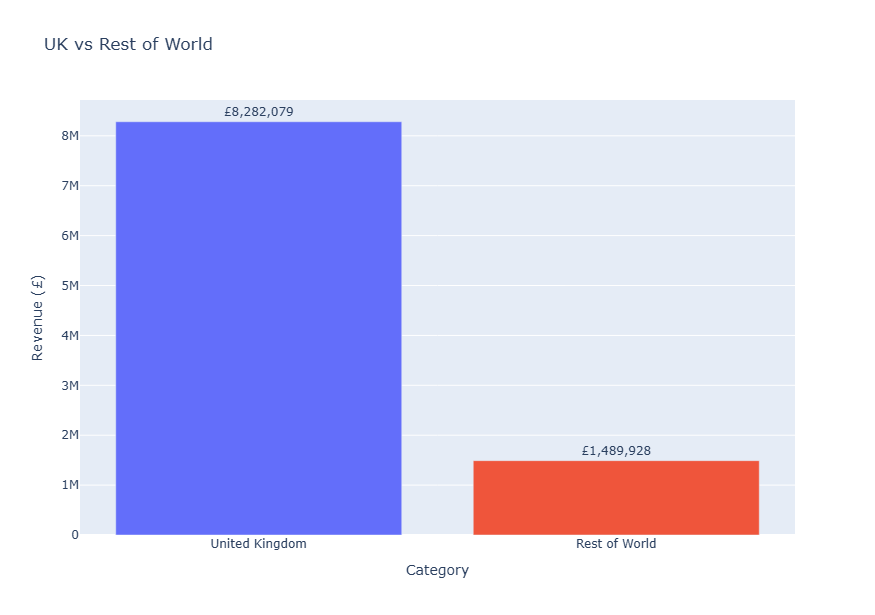

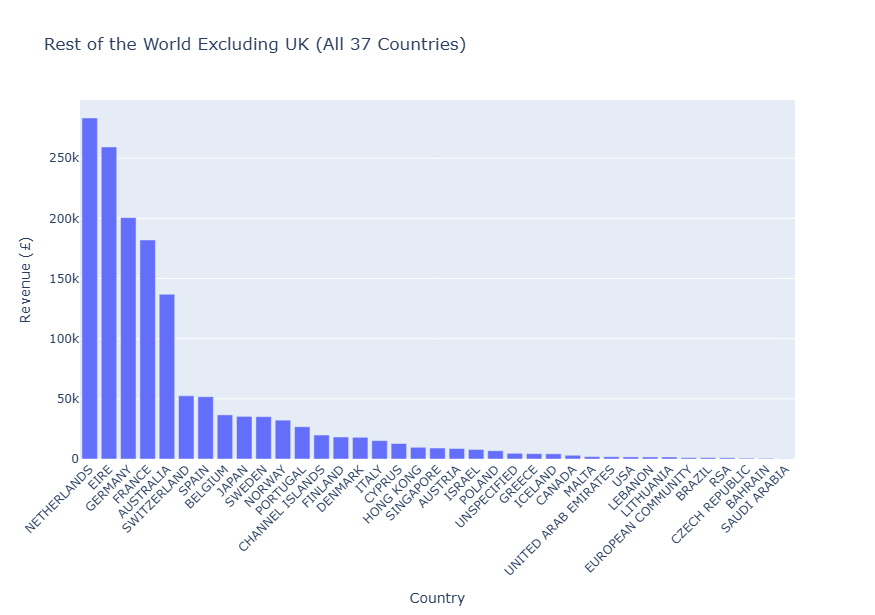

In [84]:
#Highest revenue generating countries generally
from plotly.subplots import make_subplots
import plotly.graph_objects as go

revenue_by_country = (
    df_final[df_final['IsProduct']]
    .groupby('Country')['Revenue'].sum()
    .sort_values(ascending=False)
    .reset_index()
)

revenue_by_country_no_uk = revenue_by_country[revenue_by_country['Country'] != 'UNITED KINGDOM']

# --- Chart 1: UK vs Rest of World ---
uk_vs_rest = pd.DataFrame({
    'Category': ['United Kingdom', 'Rest of World'],
    'Revenue': [
        revenue_by_country[revenue_by_country['Country'] == 'UNITED KINGDOM']['Revenue'].values[0],
        revenue_by_country_no_uk['Revenue'].sum()
    ]
})

fig1 = px.bar(uk_vs_rest, x='Category', y='Revenue', title='UK vs Rest of World',
              color='Category', text='Revenue')
fig1.update_traces(texttemplate='£%{text:,.0f}', textposition='outside')
fig1.update_layout(showlegend=False, height=600, yaxis_title='Revenue (£)')
fig1.show()

# --- Chart 2: All 37 countries excluding UK ---
fig2 = px.bar(revenue_by_country_no_uk, x='Country', y='Revenue',
              title='Rest of the World Excluding UK (All 37 Countries)')
fig2.update_layout(
    xaxis_title='Country', 
    yaxis_title='Revenue (£)', 
    height=600,
    width=1400,
    xaxis_tickangle=-45
)
fig2.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_10164\445899579.py:14: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



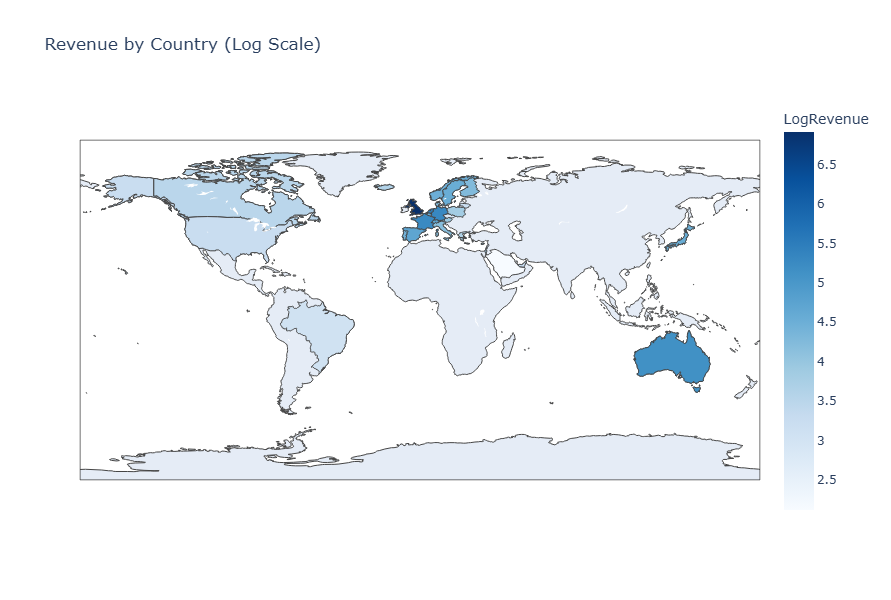

In [85]:
#Choropleth map

#Prepare the data
revenue_by_country_map = (
    df_final[df_final['IsProduct']]
    .groupby('Country')['Revenue'].sum()
    .reset_index()
)

import numpy as np

revenue_by_country_map['LogRevenue'] = np.log10(revenue_by_country_map['Revenue'])

fig = px.choropleth(
    revenue_by_country_map,
    locations='Country',
    locationmode='country names',
    color='LogRevenue',
    hover_name='Country',
    hover_data={'Revenue': ':,.0f', 'LogRevenue': False},  # show real revenue on hover, hide log value
    color_continuous_scale='Blues',
    title='Revenue by Country (Log Scale)'
)
fig.update_layout(height=600)
fig.show()

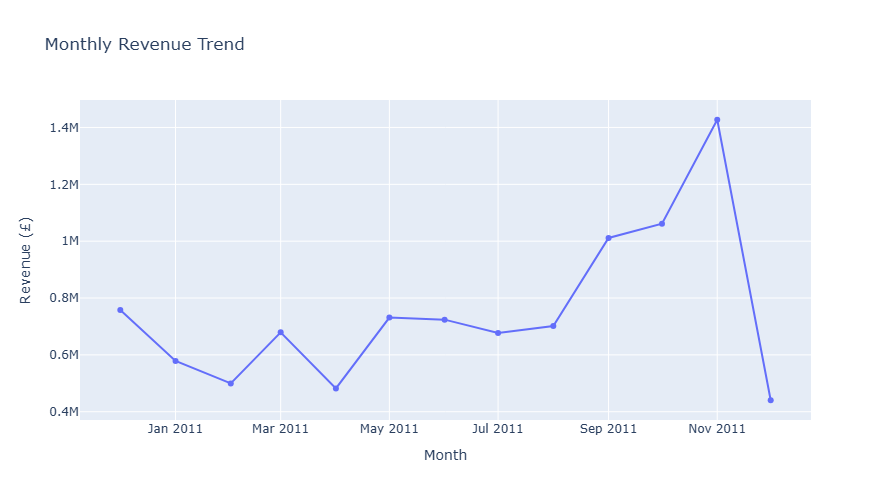

In [86]:
#Monthly sales trends 
#Which month generates the highest sales (revenue) generally?
monthly_revenue = (
    df_final[df_final['IsProduct']]
    .groupby(df_final['InvoiceDate'].dt.to_period('M'))['Revenue']
    .sum()
    .reset_index()
)
monthly_revenue['InvoiceDate'] = monthly_revenue['InvoiceDate'].astype(str)

fig = px.line(monthly_revenue, x='InvoiceDate', y='Revenue', markers=True,
              title='Monthly Revenue Trend')
fig.update_layout(xaxis_title='Month', yaxis_title='Revenue (£)', height=500)
fig.show()

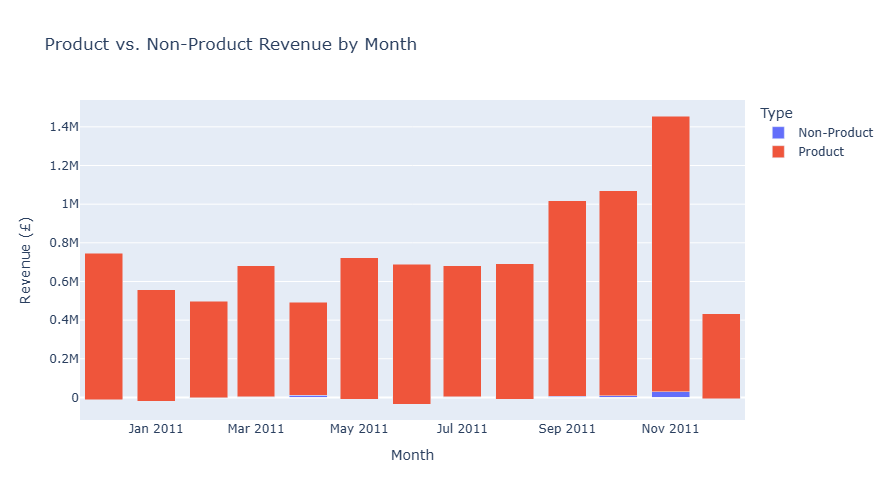

In [87]:
#Product vs non-product revenue month on month
df_final['OrderMonth'] = df_final['InvoiceDate'].dt.to_period('M')

monthly_type_revenue = (
    df_final.groupby(['OrderMonth', 'IsProduct'])['Revenue']
    .sum()
    .reset_index()
)
monthly_type_revenue['OrderMonth'] = monthly_type_revenue['OrderMonth'].astype(str)
monthly_type_revenue['Type'] = monthly_type_revenue['IsProduct'].map({True: 'Product', False: 'Non-Product'})

fig = px.bar(monthly_type_revenue, x='OrderMonth', y='Revenue', color='Type',
             title='Product vs. Non-Product Revenue by Month', barmode='stack')
fig.update_layout(xaxis_title='Month', yaxis_title='Revenue (£)', height=500)
fig.show()

In [88]:
#Check the breadth of the date distribution
print(df_final['InvoiceDate'].min())
print(df_final['InvoiceDate'].max())

2010-12-01 08:26:00
2011-12-09 12:50:00


In [89]:
#Product of the month by revenue
monthly_top_product = (
    df_final[df_final['IsProduct']]
    .groupby([df_final['InvoiceDate'].dt.to_period('M'), 'Description'])['Revenue']
    .sum()
    .reset_index()
    .sort_values(['InvoiceDate', 'Revenue'], ascending=[True, False])
    .groupby('InvoiceDate')
    .head(1)
)
print(monthly_top_product)

      InvoiceDate                          Description   Revenue
2034      2010-12             REGENCY CAKESTAND 3 TIER  26722.16
5214      2011-01   WHITE HANGING HEART T-LIGHT HOLDER  15227.30
7044      2011-02             REGENCY CAKESTAND 3 TIER  10491.54
9533      2011-03             REGENCY CAKESTAND 3 TIER  16817.85
12013     2011-04             REGENCY CAKESTAND 3 TIER  14280.90
14219     2011-05                        PARTY BUNTING  19093.30
16821     2011-06       PICNIC BASKET WICKER 60 PIECES  39619.50
19467     2011-07                        PARTY BUNTING  14576.50
21704     2011-08              JUMBO BAG RED RETROSPOT  10441.77
25372     2011-09  SET OF TEA COFFEE SUGAR TINS PANTRY   9971.51
27927     2011-10             REGENCY CAKESTAND 3 TIER  12635.34
30771     2011-11                   RABBIT NIGHT LIGHT  34343.77
33403     2011-12                   RABBIT NIGHT LIGHT   9603.45


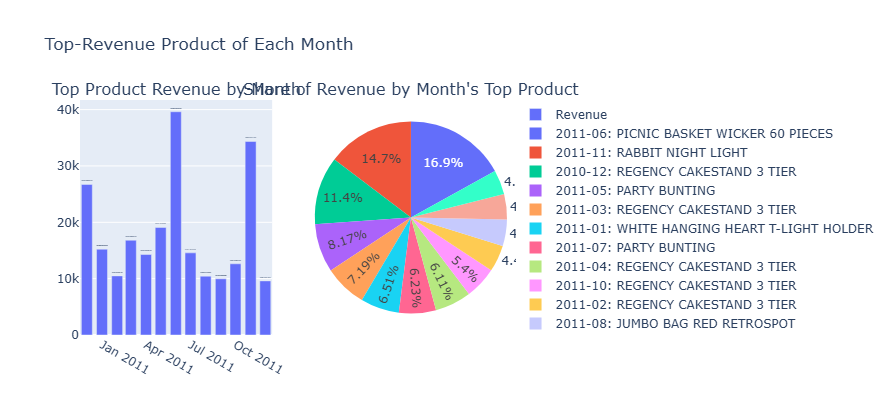

In [90]:
#Visualization
from plotly.subplots import make_subplots
import plotly.graph_objects as go

monthly_top_product['InvoiceDate'] = monthly_top_product['InvoiceDate'].astype(str)
monthly_top_product['Label'] = monthly_top_product['InvoiceDate'] + ': ' + monthly_top_product['Description']

fig = make_subplots(
    rows=1, cols=2, 
    specs=[[{'type': 'bar'}, {'type': 'domain'}]],  
    subplot_titles=('Top Product Revenue by Month', 'Share of Revenue by Month\'s Top Product')
)

fig.add_trace(
    go.Bar(x=monthly_top_product['InvoiceDate'], y=monthly_top_product['Revenue'],
           text=monthly_top_product['Description'], textposition='outside',
           name='Revenue'),
    row=1, col=1
)

fig.add_trace(
    go.Pie(labels=monthly_top_product['Label'], values=monthly_top_product['Revenue'],
           textinfo='percent', name='Revenue Share'),
    row=1, col=2
)

fig.update_layout(
    title_text='Top-Revenue Product of Each Month',
    height=400,
    width=1400,
    showlegend=True
)
fig.show()

In [91]:
#Monthly product performance — (Every product's revenue/quantity that month)

df_final['YearMonth'] = df_final['InvoiceDate'].dt.to_period('M').astype(str)

month_dd = widgets.Dropdown(options=sorted(df_final['YearMonth'].unique()), description='Month:')
output_c = widgets.Output()

def update_monthly_table(change=None):
    output_c.clear_output()
    with output_c:
        filtered = (
            df_final[(df_final['IsProduct']) & (df_final['YearMonth'] == month_dd.value)]
            .groupby('Description')
            .agg(Revenue=('Revenue', 'sum'), Quantity=('Quantity', 'sum'))
            .sort_values('Revenue', ascending=False)
            .reset_index()
        )
        display(filtered)

month_dd.observe(update_monthly_table, names='value')
display(month_dd, output_c)
update_monthly_table()

Dropdown(description='Month:', options=('2010-12', '2011-01', '2011-02', '2011-03', '2011-04', '2011-05', '201…

Output()

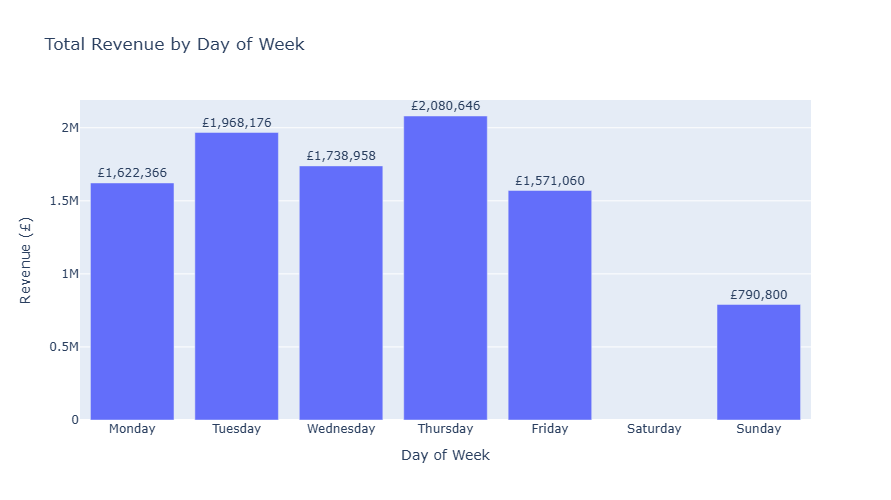

In [92]:
#Time-series Analysis
#Sales by day of the week
df_final['DayOfWeek'] = df_final['InvoiceDate'].dt.day_name()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

revenue_by_day = (
    df_final[df_final['IsProduct']]
    .groupby('DayOfWeek')['Revenue'].sum()
    .reindex(day_order)
    .reset_index()
)

fig = px.bar(revenue_by_day, x='DayOfWeek', y='Revenue', text='Revenue',
             title='Total Revenue by Day of Week')
fig.update_traces(texttemplate='£%{text:,.0f}', textposition='outside')
fig.update_layout(xaxis_title='Day of Week', yaxis_title='Revenue (£)', height=500)
fig.show()

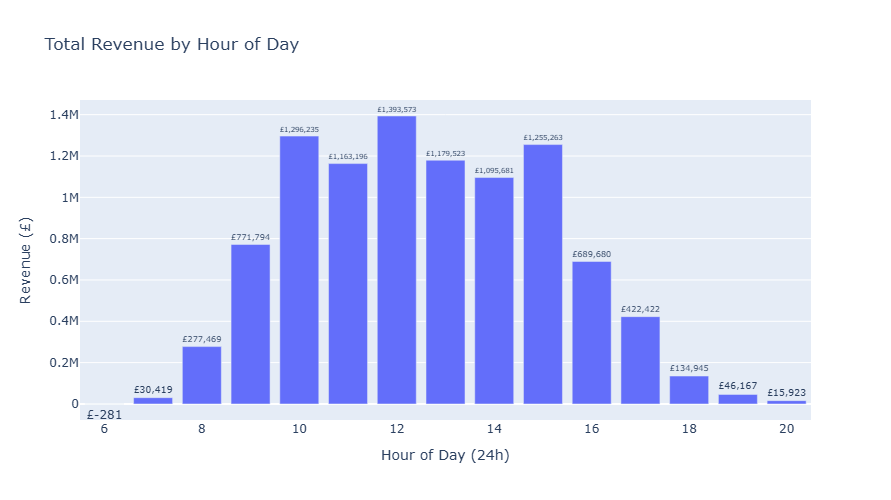

In [93]:
#Sales by hour of the day
df_final['Hour'] = df_final['InvoiceDate'].dt.hour

revenue_by_hour = (
    df_final[df_final['IsProduct']]
    .groupby('Hour')['Revenue'].sum()
    .reset_index()
)

fig = px.bar(revenue_by_hour, x='Hour', y='Revenue', text='Revenue',
             title='Total Revenue by Hour of Day')
fig.update_traces(texttemplate='£%{text:,.0f}', textposition='outside')
fig.update_layout(xaxis_title='Hour of Day (24h)', yaxis_title='Revenue (£)', height=500)
fig.show()

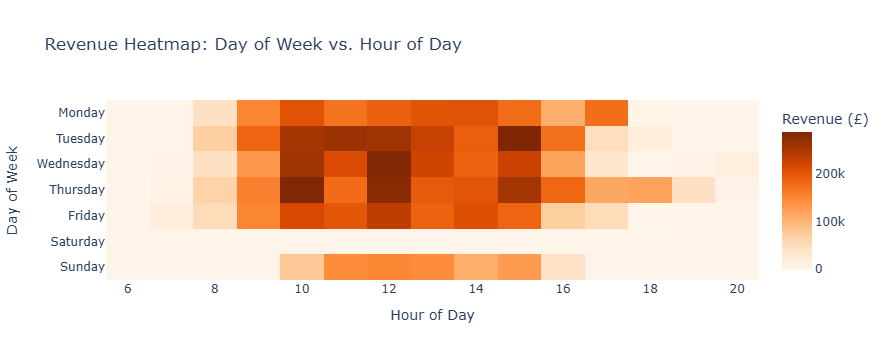

In [94]:
#When is the business the busiest?
#Combined heatmap — Day of Week × Hour
heatmap_data = (
    df_final[df_final['IsProduct']]
    .groupby(['DayOfWeek', 'Hour'])['Revenue'].sum()
    .reset_index()
    .pivot(index='DayOfWeek', columns='Hour', values='Revenue')
    .reindex(day_order)
    .fillna(0)
)

fig = px.imshow(heatmap_data,
                 title='Revenue Heatmap: Day of Week vs. Hour of Day',
                 labels={'x': 'Hour of Day', 'y': 'Day of Week', 'color': 'Revenue (£)'},
                 aspect='auto', color_continuous_scale='Oranges')
fig.show()

In [95]:
#Most purchased goods (by total quantity sold)
#e.g. A product could sell 80,000 units in a single bulk order (high quantity, low order count)
top_n_slider3 = widgets.IntSlider(value=10, min=1, max=40, step=1, description='Top N:')
output3 = widgets.Output()

def update_qty_chart(change=None):
    output3.clear_output()
    most_purchased_qty = (
        df_final[df_final['IsProduct']]
        .groupby('Description')['Quantity'].sum()
        .reset_index()
        .sort_values('Quantity', ascending=False)
        .head(top_n_slider3.value)
    )
    fig = px.bar(most_purchased_qty, x='Quantity', y='Description', orientation='h',
                 text='Quantity', title=f'Top {top_n_slider3.value} Most Purchased Products (by Quantity)')
    fig.update_traces(textposition='outside')
    fig.update_layout(yaxis=dict(categoryorder='total ascending'), height=650, showlegend=False)
    with output3:
        fig.show()

top_n_slider3.observe(update_qty_chart, names='value')
display(top_n_slider3, output3)
update_qty_chart()

IntSlider(value=10, description='Top N:', max=40, min=1)

Output()

In [96]:
#Most purchased goods by number of distinct orders
#How many separate invoices included this product? (Low quantity, high order count)
top_n_slider4 = widgets.IntSlider(value=10, min=1, max=40, step=1, description='Top N:')
output4 = widgets.Output()

def update_orders_chart(change=None):
    output4.clear_output()
    most_purchased_orders = (
        df_final[df_final['IsProduct']]
        .groupby('Description')['InvoiceNo'].nunique()
        .reset_index(name='OrderCount')
        .sort_values('OrderCount', ascending=False)
        .head(top_n_slider4.value)
    )
    fig = px.bar(most_purchased_orders, x='OrderCount', y='Description', orientation='h',
                 text='OrderCount', title=f'Top {top_n_slider4.value} Most Purchased Products (by Number of Orders)')
    fig.update_traces(textposition='outside')
    fig.update_layout(yaxis=dict(categoryorder='total ascending'), height=650, showlegend=False)
    with output4:
        fig.show()

top_n_slider4.observe(update_orders_chart, names='value')
display(top_n_slider4, output4)
update_orders_chart()

IntSlider(value=10, description='Top N:', max=40, min=1)

Output()

In [97]:
#BASKET ANALYSIS
#Which products get bought together? (Appear together in an invoice?)

#First group ALL products by InvoiveNo
baskets = (
    df_final[df_final['IsProduct']]
    .groupby('InvoiceNo')['Description']
    .apply(list)
)
print(baskets.head())
print("Total invoices:", len(baskets))

InvoiceNo
536365    [WHITE HANGING HEART T-LIGHT HOLDER, WHITE MET...
536366    [HAND WARMER UNION JACK, HAND WARMER RED POLKA...
536367    [ASSORTED COLOUR BIRD ORNAMENT, POPPY'S PLAYHO...
536368    [JAM MAKING SET WITH JARS, RED COAT RACK PARIS...
536369                           [BATH BUILDING BLOCK WORD]
Name: Description, dtype: object
Total invoices: 25299


count    25299.000000
mean        20.874422
std         42.749625
min          1.000000
25%          2.000000
50%         10.000000
75%         24.000000
max       1107.000000
Name: BasketSize, dtype: float64


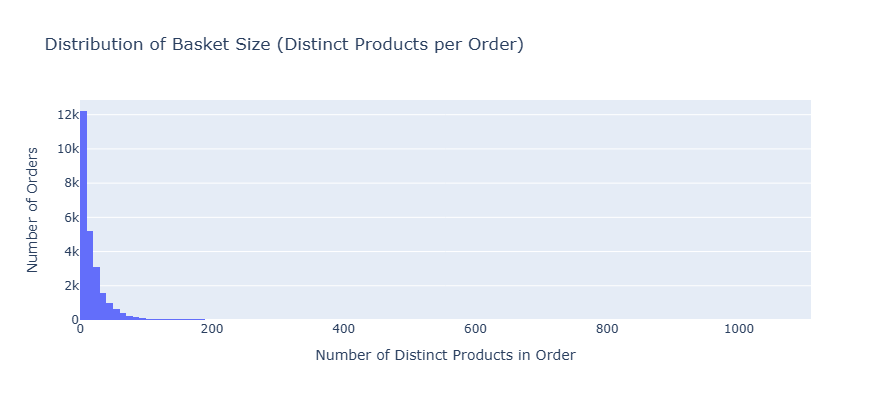

In [98]:
#How many distinct products does a typical order contain, regardless of which ones?

basket_sizes = (
    df_final[df_final['IsProduct']]
    .groupby('InvoiceNo')['Description']
    .nunique()
    .reset_index(name='BasketSize')
)

print(basket_sizes['BasketSize'].describe())

fig = px.histogram(basket_sizes, x='BasketSize', nbins=150,
                    title='Distribution of Basket Size (Distinct Products per Order)')
fig.update_layout(xaxis_title='Number of Distinct Products in Order', yaxis_title='Number of Orders', height=400)
fig.show()

In [99]:
#Find the most common product PAIRS across all invoices
from itertools import combinations
from collections import Counter

pair_counts = Counter()

for products in baskets:
    unique_products = set(products)  # avoid double-counting if a product appears twice in one invoice
    if len(unique_products) > 1:
        for pair in combinations(sorted(unique_products), 2):
            pair_counts[pair] += 1

# Convert to a sorted DataFrame
pairs_df = pd.DataFrame(pair_counts.items(), columns=['Pair', 'Count']).sort_values('Count', ascending=False)
pairs_df[['ProductA', 'ProductB']] = pd.DataFrame(pairs_df['Pair'].tolist(), index=pairs_df.index)
pairs_df = pairs_df[['ProductA', 'ProductB', 'Count']].reset_index(drop=True)

print(pairs_df.head(20))

                             ProductA                           ProductB  \
0             JUMBO BAG PINK POLKADOT            JUMBO BAG RED RETROSPOT   
1     GREEN REGENCY TEACUP AND SAUCER    ROSES REGENCY TEACUP AND SAUCER   
2             JUMBO BAG RED RETROSPOT             JUMBO STORAGE BAG SUKI   
3             JUMBO BAG RED RETROSPOT  JUMBO SHOPPER VINTAGE RED PAISLEY   
4             LUNCH BAG RED RETROSPOT              LUNCH BAG SUKI DESIGN   
5              LUNCH BAG BLACK SKULL.            LUNCH BAG RED RETROSPOT   
6          ALARM CLOCK BAKELIKE GREEN           ALARM CLOCK BAKELIKE RED   
7     GREEN REGENCY TEACUP AND SAUCER     PINK REGENCY TEACUP AND SAUCER   
8      PINK REGENCY TEACUP AND SAUCER    ROSES REGENCY TEACUP AND SAUCER   
9             LUNCH BAG PINK POLKADOT            LUNCH BAG RED RETROSPOT   
10      JUMBO BAG BAROQUE BLACK WHITE            JUMBO BAG RED RETROSPOT   
11            JUMBO BAG RED RETROSPOT            LUNCH BAG RED RETROSPOT   
12          

In [100]:
#Interactive drop-down (pick a product, see what it's most often bought alongside)
product_dd = widgets.Dropdown(
    options=sorted(set(pairs_df['ProductA']).union(set(pairs_df['ProductB']))),
    description='Product:'
)
output_pairs = widgets.Output()

def update_pairs_table(change=None):
    output_pairs.clear_output()
    with output_pairs:
        selected = product_dd.value
        related = pairs_df[(pairs_df['ProductA'] == selected) | (pairs_df['ProductB'] == selected)].copy()
        related['PairedWith'] = related.apply(
            lambda row: row['ProductB'] if row['ProductA'] == selected else row['ProductA'], axis=1
        )
        related = related[['PairedWith', 'Count']].sort_values('Count', ascending=False).reset_index(drop=True)
        display(related.head(15))

product_dd.observe(update_pairs_table, names='value')
display(product_dd, output_pairs)
update_pairs_table()

Dropdown(description='Product:', options=('*BOOMBOX IPOD CLASSIC', '*USB OFFICE MIRROR BALL', '10 COLOUR SPACE…

Output()

In [101]:
#What % of untis sold for a specific item end up returned?
# Separate sales (positive quantity) from returns (negative quantity)
product_returns = (
    df_final[df_final['IsProduct']]
    .groupby('Description')
    .agg(
        UnitsSold=('Quantity', lambda x: x[x > 0].sum()),
        UnitsReturned=('Quantity', lambda x: abs(x[x < 0].sum()))
    )
    .reset_index()
)

# Return rate as a percentage
product_returns['ReturnRate%'] = (
    product_returns['UnitsReturned'] / product_returns['UnitsSold'] * 100
).round(2)

# Filter out products with very low sales volume (avoids misleading %s from tiny sample sizes)
product_returns_filtered = product_returns[product_returns['UnitsSold'] >= 100]

print(product_returns_filtered.sort_values('ReturnRate%', ascending=False).head(20))

                              Description  UnitsSold  UnitsReturned  \
972                               DAMAGED        192           9365   
719                                 CHECK       1217          13381   
3564     SPRIG LAVENDER ARTIFICIAL FLOWER        224            406   
3504       SMALL SILVER TRELLIS CANDLEPOT        224            332   
3517    SMALLFOLKART BAUBLE CHRISTMAS DEC        723           1035   
260       ASSORTED SANSKRIT MINI NOTEBOOK        109            139   
4114                  WRONGLY CODED 20713        800           1000   
1893            KEEP OUT BOYS DOOR HANGER        143            168   
112                                     ?       8112           9496   
1928     LADYBIRD + BEE RAFFIA FOOD COVER        124            141   
2123    MEDIUM WHITE/PINK ROSE ART FLOWER        127            127   
2467            PAPER CRAFT LITTLE BIRDIE      80995          80995   
1797  INCORRECTLY CREDITED C550456 SEE 47       1300           1300   
3038  

In [102]:
#Return rate month by month 
#Is it increasing, decreasing or is it stable?

#Calculate monthly sales, returns, and the return rate
df_final['OrderMonth'] = df_final['InvoiceDate'].dt.to_period('M')

monthly_returns = (
    df_final[df_final['IsProduct']]
    .groupby('OrderMonth')
    .agg(
        UnitsSold=('Quantity', lambda x: x[x > 0].sum()),
        UnitsReturned=('Quantity', lambda x: abs(x[x < 0].sum()))
    )
    .reset_index()
)

monthly_returns['ReturnRate%'] = (monthly_returns['UnitsReturned'] / monthly_returns['UnitsSold'] * 100).round(2)
monthly_returns['OrderMonth'] = monthly_returns['OrderMonth'].astype(str)

print(monthly_returns)

fig = px.line(monthly_returns, x='OrderMonth', y='ReturnRate%', markers=True,
              title='Return Rate Trend Over Time')
fig.update_layout(xaxis_title='Month', yaxis_title='Return Rate (%)', height=500)
fig.show()

   OrderMonth  UnitsSold  UnitsReturned  ReturnRate%
0     2010-12     360607          20023         5.55
1     2011-01     395672          88688        22.41
2     2011-02     285770           8436         2.95
3     2011-03     382607          31801         8.31
4     2011-04     311017          23032         7.41
5     2011-05     397541          17223         4.33
6     2011-06     393251          52541        13.36
7     2011-07     405072          16340         4.03
8     2011-08     423944          18132         4.28
9     2011-09     572547          25155         4.39
10    2011-10     624941          55930         8.95
11    2011-11     763090          30997         4.06
12    2011-12     313451          88676        28.29


In [103]:
#Customer pruchasing behaviour
#Build df_customer first (real customers only, excluding the -1 placeholder).
df_customer = df_final[df_final['CustomerID'] != -1].copy()
print(df_customer.shape)

(401604, 14)


In [104]:
#Revenue, order count, items bought, per customer:
customer_summary = df_customer[df_customer['IsProduct']].groupby('CustomerID').agg(
    TotalRevenue=('Revenue', 'sum'),
    TotalOrders=('InvoiceNo', 'nunique'),
    TotalItems=('Quantity', 'sum'),
    FirstPurchase=('InvoiceDate', 'min'),
    LastPurchase=('InvoiceDate', 'max')
).reset_index()

customer_summary['AvgOrderValue'] = customer_summary['TotalRevenue'] / customer_summary['TotalOrders']
customer_summary = customer_summary.sort_values('TotalRevenue', ascending=False)
print(customer_summary.head(20))

      CustomerID  TotalRevenue  TotalOrders  TotalItems       FirstPurchase  \
1700       14646     278778.02           74      197132 2010-12-20 10:09:00   
4224       18102     259657.30           60       64124 2010-12-07 16:42:00   
3750       17450     189575.53           49       69021 2010-12-07 09:23:00   
1892       14911     128768.24          242       77073 2010-12-01 14:05:00   
55         12415     123638.18           24       77242 2011-01-06 11:12:00   
1342       14156     113685.77           64       56896 2010-12-02 17:08:00   
3793       17511      88138.20           45       63014 2010-12-01 10:19:00   
3196       16684      65920.12           30       49391 2010-12-16 17:34:00   
1002       13694      62961.54           57       61904 2010-12-01 12:12:00   
2716       16029      60369.93           66       33687 2010-12-01 09:57:00   
2189       15311      59284.19          118       37673 2010-12-01 09:41:00   
566        13089      57322.13          118       30

In [105]:
#Top customers by revenue (generally)
top_n_slider5 = widgets.IntSlider(value=10, min=1, max=100, step=1, description='Top N:')
output5 = widgets.Output()

def update_customer_chart(change=None):
    output5.clear_output()
    n = top_n_slider5.value
    top_customers = customer_summary.head(n).copy()
    top_customers['CustomerID'] = top_customers['CustomerID'].astype(str)
    
    fig = px.bar(top_customers, x='TotalRevenue', y='CustomerID',
                 orientation='h', text='TotalRevenue',
                 title=f'Top {n} Customers by Revenue')
    fig.update_traces(texttemplate='£%{text:,.0f}', textposition='outside')
    fig.update_layout(
        yaxis=dict(categoryorder='total ascending', tickmode='linear'),  # force every label to show
        yaxis_title='CustomerID', 
        height=max(650, n * 25),  # scale height based on how many bars are shown
        showlegend=False
    )
    with output5:
        fig.show()

top_n_slider5.observe(update_customer_chart, names='value')
display(top_n_slider5, output5)
update_customer_chart()

IntSlider(value=10, description='Top N:', min=1)

Output()

In [106]:
# Repeat purchase rate — how many customers bought once vs. multiple times (Loyalty indicator):
customer_summary['CustomerType'] = customer_summary['TotalOrders'].apply(
    lambda x: 'One-Time Buyer' if x == 1 else 'Repeat Customer'
)

repeat_rate = customer_summary['CustomerType'].value_counts().reset_index()
repeat_rate.columns = ['CustomerType', 'Count']

fig = px.pie(repeat_rate, values='Count', names='CustomerType',
             title='One-Time vs. Repeat Customers')
fig.update_traces(textinfo='percent+label+value')
fig.show()

In [107]:
#Customer type (repeat vs one-time), sort by total revenue, number of orders, total number of items
customer_type_dd = widgets.Dropdown(
    options=['All Customers', 'Repeat Customer', 'One-Time Buyer'],
    value='All Customers', description='Type:'
)
sort_metric_dd = widgets.Dropdown(
    options=['TotalRevenue', 'TotalOrders', 'TotalItems', 'AvgOrderValue'],
    value='TotalRevenue', description='Sort by:'
)
output_b = widgets.Output()

def update_customer_table(change=None):
    output_b.clear_output()
    with output_b:
        filtered = customer_summary.copy()
        if customer_type_dd.value != 'All Customers':
            filtered = filtered[filtered['CustomerType'] == customer_type_dd.value]
        filtered = filtered.sort_values(sort_metric_dd.value, ascending=False).reset_index(drop=True)
        display(filtered)

customer_type_dd.observe(update_customer_table, names='value')
sort_metric_dd.observe(update_customer_table, names='value')
display(customer_type_dd, sort_metric_dd, output_b)
update_customer_table()

Dropdown(description='Type:', options=('All Customers', 'Repeat Customer', 'One-Time Buyer'), value='All Custo…

Dropdown(description='Sort by:', options=('TotalRevenue', 'TotalOrders', 'TotalItems', 'AvgOrderValue'), value…

Output()

In [108]:
#Repeat purchase timing
#Every return customer returns after every X days

#Get each customer's list of purchase dates (distinct order dates, not every line item)
customer_order_dates = (
    df_customer[df_customer['IsProduct']]
    .groupby('CustomerID')['InvoiceDate']
    .apply(lambda x: sorted(x.unique()))
)

#Calculate the gap (in days) between consecutive orders for each customer
def calculate_gaps(dates):
    if len(dates) < 2:
        return None  # one-time buyers have no gap to measure
    gaps = [(dates[i+1] - dates[i]).days for i in range(len(dates)-1)]
    return gaps

customer_gaps = customer_order_dates.apply(calculate_gaps).dropna()

# Flatten into a single list of all gaps (across all repeat customers) for an overall distribution:
all_gaps = [gap for gaps in customer_gaps for gap in gaps]
gaps_df = pd.DataFrame({'DaysBetweenOrders': all_gaps})

print(gaps_df['DaysBetweenOrders'].describe())

fig = px.histogram(gaps_df, x='DaysBetweenOrders', nbins=50,
                    title='Distribution of Days Between Repeat Purchases')
fig.update_layout(xaxis_title='Days Between Orders', yaxis_title='Number of Occurrences', height=500)
fig.show()

count    17289.000000
mean        33.262421
std         48.980581
min          0.000000
25%          4.000000
50%         14.000000
75%         42.000000
max        365.000000
Name: DaysBetweenOrders, dtype: float64


In [109]:
#Per-customer average gap
avg_gap_per_customer = customer_gaps.apply(lambda x: sum(x)/len(x)).reset_index()
avg_gap_per_customer.columns = ['CustomerID', 'AvgDaysBetweenOrders']
avg_gap_per_customer = avg_gap_per_customer.sort_values('AvgDaysBetweenOrders')

print(avg_gap_per_customer.head(20))  # customers who reorder fastest
print(avg_gap_per_customer.tail(10))  # customers who reorder slowest

      CustomerID  AvgDaysBetweenOrders
0          12346                   0.0
2379       16986                   0.0
938        14154                   0.0
902        14087                   0.0
2431       17078                   0.0
2436       17084                   0.0
2518       17267                   0.0
2558       17357                   0.0
706        13711                   0.0
698        13693                   0.0
695        13684                   0.0
2580       17391                   0.0
2583       17397                   0.0
656        13598                   0.0
2639       17501                   0.0
2661       17545                   0.0
2695       17608                   0.0
487        13271                   0.0
2940       18110                   0.0
2909       18048                   0.0
      CustomerID  AvgDaysBetweenOrders
1280       14777                 353.0
1093       14448                 354.0
647        13579                 354.0
2964       18156         

In [110]:
#Is the business acquiring new customers or solely relying on repeat customers?

# Find each customer's very first InvoiceDate (exact timestamp, not just month)
customer_first_invoice = (
    df_customer[df_customer['IsProduct']]
    .groupby('CustomerID')['InvoiceDate']
    .min()
    .rename('FirstPurchaseDate')
)

df_customer_tagged = df_customer[df_customer['IsProduct']].copy()
df_customer_tagged = df_customer_tagged.merge(customer_first_invoice, on='CustomerID')

# Now compare exact InvoiceDate (or InvoiceNo) to the customer's true first purchase
df_customer_tagged['CustomerStatus'] = df_customer_tagged.apply(
    lambda row: 'New' if row['InvoiceDate'] == row['FirstPurchaseDate'] else 'Returning',
    axis=1
)

df_customer_tagged['OrderMonth'] = df_customer_tagged['InvoiceDate'].dt.to_period('M')

monthly_customer_type = (
    df_customer_tagged.groupby(['OrderMonth', 'CustomerStatus'])['CustomerID']
    .nunique()
    .reset_index(name='CustomerCount')
)
monthly_customer_type['OrderMonth'] = monthly_customer_type['OrderMonth'].astype(str)
print(monthly_customer_type)

fig = px.bar(monthly_customer_type, x='OrderMonth', y='CustomerCount', color='CustomerStatus',
             title='New vs. Returning Customers by Month', barmode='stack')
fig.update_layout(xaxis_title='Month', yaxis_title='Number of Customers', height=500)
fig.show()

   OrderMonth CustomerStatus  CustomerCount
0     2010-12            New            947
1     2010-12      Returning            354
2     2011-01            New            420
3     2011-01      Returning            461
4     2011-02            New            378
5     2011-02      Returning            486
6     2011-03            New            439
7     2011-03      Returning            662
8     2011-04            New            298
9     2011-04      Returning            661
10    2011-05            New            279
11    2011-05      Returning            858
12    2011-06            New            235
13    2011-06      Returning            857
14    2011-07            New            186
15    2011-07      Returning            826
16    2011-08            New            167
17    2011-08      Returning            840
18    2011-09            New            299
19    2011-09      Returning           1047
20    2011-10            New            353
21    2011-10      Returning    

In [111]:
#RFM segmentation
#Calculate the three components per customer:
# a)Recency — days since their last purchase (lower = more recently active = better)
# b)Frequency — how many distinct orders they've placed (higher = more engaged = better)
# c)Monetary — total revenue they've generated (higher = more valuable = better)

snapshot_date = df_customer['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_customer[df_customer['IsProduct']].groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('Revenue', 'sum')
).reset_index()

print(rfm.head(10))
print(rfm.describe())

   CustomerID  Recency  Frequency  Monetary
0       12346      326          2      0.00
1       12347        2          7   4310.00
2       12348       75          4   1437.24
3       12349       19          1   1457.55
4       12350      310          1    294.40
5       12352       36          8   1265.41
6       12353      204          1     89.00
7       12354      232          1   1079.40
8       12355      214          1    459.40
9       12356       23          3   2487.43
         CustomerID      Recency    Frequency       Monetary
count   4363.000000  4363.000000  4363.000000    4363.000000
mean   15299.772863    92.154710     4.993812    1894.448071
std     1721.852042   100.960982     9.083984    8265.172521
min    12346.000000     1.000000     1.000000   -1192.200000
25%    13813.500000    17.000000     1.000000     292.175000
50%    15299.000000    50.000000     3.000000     642.320000
75%    16777.500000   143.000000     5.000000    1584.030000
max    18287.000000   374.00

In [112]:
#Score each metric on a 1–5 scale using quantiles (5 = best, 1 = worst)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1]).astype(int)  # lower recency = higher score
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

In [113]:
#Translate scores into meaningful business segments
def segment_customer(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2:
        return 'Lost'
    else:
        return 'Loyal Customers'  # everything else defaults here instead of "Needs Attention"

rfm['Segment'] = rfm.apply(segment_customer, axis=1)
print(rfm['Segment'].value_counts())

Segment
Loyal Customers    1339
Lost               1056
Champions           969
At Risk             671
New Customers       328
Name: count, dtype: int64


In [114]:
#Champions — bought recently, buy often, spend a lot. Your best customers, full stop.
#Loyal Customers — buy fairly recently and fairly often, but maybe not quite at "top spender" level. Solid, dependable repeat buyers.
#New Customers — bought very recently, but haven't ordered many times yet. Too early to tell if they'll become loyal or fade away.
#At Risk — used to buy often, but haven't purchased in a while. Once-good customers who are drifting away — worth re-engaging before they're gone for good.
#Lost — haven't bought in a long time AND never ordered much even when they were active. Largely written off.

In [115]:
segment_counts = rfm['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']

fig = px.bar(segment_counts, x='Segment', y='Count', text='Count',
             title='Customer Segments (RFM Analysis)')
fig.update_traces(textposition='outside')
fig.update_layout(xaxis_title='Segment', yaxis_title='Number of Customers', height=500)
fig.show()